# Insurance Claims Modelling — Unified Pipeline
## Claim Frequency · Claim Severity · Pure Premium

**Single pipeline** — data loaded once, features built once, split defined once.

```
Section 1  Setup & constants
Section 2  Load all four tables (once)
Section 3  Shared joins → pol_meta
Section 4  Shared exposure table
Section 5  Shared external features
Section 6  Segment table  ← used by Frequency + Pure Premium
Section 7  Severity table ← used by Severity model
Section 8  One temporal split applied to both tables
           ↓              ↓               ↓
        Part A          Part B          Part C
     Frequency        Severity       Pure Premium
     Poisson GLM    Gamma GLM       Tweedie GLM
```

**Train:** 2021–2022 · **Validation:** 2023 · **Test (held-out):** 2024

### Pure premium offset fix
The original model incorrectly used `log(earned_exposure)` as a GLM offset.
Pure premium = total_claims / exposure — exposure is already divided out.
Adding it again as an offset caused predictions to scale with the exposure level,
collapsing toward zero as the portfolio stabilised in 2023–2024.

**Fix:** Remove the offset. Pass `earned_exposure_months` as `freq_weights` instead.
Weights control credibility (larger segments count more) without distorting the scale.


## 1. Setup — imports & constants

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', '{:.4f}'.format)

# ── Constants ──
DATA_PATH   = '/mnt/user-data/uploads/insurance_data_features.xlsx'
RANDOM_SEED = 42
TRAIN_YEARS = [2021, 2022]
VAL_YEAR    = 2023
TEST_YEAR   = 2024

# ── Shared metrics ──
def poisson_deviance(y, yhat):
    yhat = np.clip(yhat, 1e-9, None)
    return 2 * np.sum(np.where(y > 0, y * np.log(y / yhat), 0) - (y - yhat)) / len(y)

def rmsle(y_true, y_pred):
    y_true = np.clip(y_true, 1, None)
    y_pred = np.clip(y_pred, 1, None)
    return np.sqrt(np.mean((np.log(y_true) - np.log(y_pred)) ** 2))

def gini(y_true, y_pred):
    dg = pd.DataFrame({'a': np.array(y_true), 'p': np.array(y_pred)})
    dg = dg.sort_values('p').reset_index(drop=True)
    cy = dg['a'].cumsum() / dg['a'].sum()
    cx = np.arange(1, len(dg)+1) / len(dg)
    return 2 * np.trapezoid(np.concatenate([[0], cy.values]),
                             np.concatenate([[0], cx])) - 1

print(f'statsmodels {sm.__version__}  xgboost {xgb.__version__}')
print(f'Train: {TRAIN_YEARS}  Val: {VAL_YEAR}  Test: {TEST_YEAR}')


statsmodels 0.14.6  xgboost 3.2.0
Train: [2021, 2022]  Val: 2023  Test: 2024


## 2. Load all tables — once

In [2]:
claims    = pd.read_excel(DATA_PATH, sheet_name='Claims')
policies  = pd.read_excel(DATA_PATH, sheet_name='Policies')
customers = pd.read_excel(DATA_PATH, sheet_name='Customers')
external  = pd.read_excel(DATA_PATH, sheet_name='External')

for name, df in [('claims',claims),('policies',policies),
                  ('customers',customers),('external',external)]:
    print(f'{name:<12}  {df.shape[0]:>6,} rows × {df.shape[1]:>2} cols')


claims         5,000 rows × 11 cols
policies      18,000 rows × 11 cols
customers     10,000 rows × 12 cols
external       1,800 rows × 10 cols


## 3. Shared joins → `pol_meta`

All cross-table joins are performed once here.
`pol_meta` is the enriched policy record used by every downstream table.


In [3]:
pol_meta = (
    policies[['Policy Id','Customer Id','Coverage Type','Start Date','End Date',
              'Annual Premium','Excess Amount','Sum Insured','Renewal Count',
              'Distribution Channel']]
    .merge(
        customers[['Customer Id','Region','Age','Gender','Income Band',
                   'Credit Score','Tenure Years','Prior Claims Count',
                   'Late Payments 12M']],
        on='Customer Id', how='left'
    )
)

# Earned exposure — years each policy was actively at risk
pol_meta['earned_exposure'] = (
    (pol_meta['End Date'] - pol_meta['Start Date']).dt.days / 365.25
)
pol_meta['start_ym'] = pol_meta['Start Date'].dt.to_period('M').astype(str)
pol_meta['end_ym']   = pol_meta['End Date'].dt.to_period('M').astype(str)

# Region onto claims (lives on customer, not claim)
claims = claims.merge(pol_meta[['Policy Id','Region']], on='Policy Id', how='left')
claims['year_month'] = claims['Claim Date'].dt.to_period('M').astype(str)
claims['year']       = claims['Claim Date'].dt.year
claims['month']      = claims['Claim Date'].dt.month

ALL_COV    = sorted(pol_meta['Coverage Type'].unique())
ALL_REG    = sorted(pol_meta['Region'].dropna().unique())
ALL_MONTHS = sorted(claims['year_month'].unique())

print(f'pol_meta: {pol_meta.shape}  |  Region nulls: {pol_meta["Region"].isnull().sum()}')
print(f'Coverage types ({len(ALL_COV)}): {ALL_COV}')
print(f'Regions        ({len(ALL_REG)}): {ALL_REG}')
print(f'Months         ({len(ALL_MONTHS)}): {ALL_MONTHS[0]} → {ALL_MONTHS[-1]}')


pol_meta: (18000, 21)  |  Region nulls: 0
Coverage types (6): ['Commercial', 'Health', 'Home', 'Life', 'Motor', 'Travel']
Regions        (10): ['East Anglia', 'London', 'Midlands', 'North East', 'North West', 'Scotland', 'South East', 'South West', 'Wales', 'Yorkshire']
Months         (48): 2021-01 → 2024-12


## 4. Shared exposure table

Built once. Used by:
- **Frequency** — `exposure_policies` as GLM offset: `log(active policies)`
- **Pure Premium** — `earned_exposure_months` as `freq_weights`


In [4]:
exp_rows = []
for ym in ALL_MONTHS:
    active = pol_meta[(pol_meta['start_ym'] <= ym) & (pol_meta['end_ym'] >= ym)]
    grp = (
        active.groupby(['Coverage Type','Region'])
        .agg(
            exposure_policies      = ('Policy Id',       'count'),
            earned_exposure_months = ('earned_exposure', lambda x: x.sum() / 12)
        )
        .reset_index()
    )
    grp['year_month'] = ym
    exp_rows.append(grp)

exposure_df = pd.concat(exp_rows, ignore_index=True)
print(f'Exposure table: {exposure_df.shape}')
print(exposure_df.describe().round(3))


Exposure table: (2880, 5)
       exposure_policies  earned_exposure_months
count          2880.0000               2880.0000
mean             82.3530                  9.0860
std              27.7530                  3.3460
min               1.0000                  0.0410
25%              69.0000                  7.4930
50%              90.0000                  9.9850
75%             101.0000                 11.4880
max             134.0000                 15.1920


## 5. Shared external features

In [5]:
ext = external.rename(columns={'Year Month': 'year_month'})
ext = ext[ext['year_month'].isin(ALL_MONTHS)].copy()

EXT_COLS = ['Region','year_month','Avg Rainfall Mm','Avg Wind Speed Kmh',
            'Flood Risk Index','Gdp Growth Rate','Cpi Inflation',
            'Unemployment Rate','Avg Property Price Gbp','Storm Event Flag']

print(f'External: {len(EXT_COLS)-2} macro/weather features across '
      f'{ext["Region"].nunique()} regions × {ext["year_month"].nunique()} months')
print(ext[EXT_COLS].head(3).to_string(index=False))


External: 8 macro/weather features across 10 regions × 48 months
Region year_month  Avg Rainfall Mm  Avg Wind Speed Kmh  Flood Risk Index  Gdp Growth Rate  Cpi Inflation  Unemployment Rate  Avg Property Price Gbp  Storm Event Flag
London    2021-01          36.2000             17.0000            2.0700           0.0130         0.0422             0.0383                  173400                 1
London    2021-02          41.3000             19.2000            1.7500           0.0121         0.0470             0.0516                  266500                 0
London    2021-03          41.3000             15.4000            1.9800           0.0129         0.0434             0.0288                  312100                 0


## 6. Segment table

**Shared by the Frequency and Pure Premium models.**

One row per `coverage_type × region × year_month`.
Contains both the frequency target (`claim_count`) and the pure premium target
(`pure_premium = total_claim_amount / earned_exposure_months`).


In [6]:
# Aggregates from claims
seg_counts  = (claims.groupby(['Coverage Type','Region','year_month'])
               .size().reset_index(name='claim_count'))
seg_amounts = (claims.groupby(['Coverage Type','Region','year_month'])['Claim Amount']
               .sum().reset_index(name='total_claim_amount'))

# Full grid — include zero-claim months
grid = pd.MultiIndex.from_product(
    [ALL_COV, ALL_REG, ALL_MONTHS],
    names=['Coverage Type','Region','year_month']
)
seg = (pd.DataFrame(index=grid).reset_index()
    .merge(seg_counts,    on=['Coverage Type','Region','year_month'], how='left')
    .merge(seg_amounts,   on=['Coverage Type','Region','year_month'], how='left')
    .merge(exposure_df,   on=['Coverage Type','Region','year_month'], how='left')
    .merge(ext[EXT_COLS], on=['Region','year_month'],                 how='left'))

seg['claim_count']            = seg['claim_count'].fillna(0).astype(int)
seg['total_claim_amount']     = seg['total_claim_amount'].fillna(0)
seg['exposure_policies']      = seg['exposure_policies'].fillna(0)
seg['earned_exposure_months'] = seg['earned_exposure_months'].fillna(0)

# ── Pure premium target ──
seg['pure_premium'] = seg['total_claim_amount'] / seg['earned_exposure_months'].clip(1e-6)
seg.loc[seg['earned_exposure_months'] == 0, 'pure_premium'] = 0

# ── Time features ──
seg['year']       = seg['year_month'].str[:4].astype(int)
seg['month']      = seg['year_month'].str[5:7].astype(int)
seg['quarter']    = ((seg['month'] - 1) // 3) + 1
seg['year_trend'] = seg['year'] - min(TRAIN_YEARS)
seg['month_sin']  = np.sin(2 * np.pi * seg['month'] / 12)
seg['month_cos']  = np.cos(2 * np.pi * seg['month'] / 12)
seg['is_winter']  = seg['month'].isin([12, 1, 2]).astype(int)

print(f'Segment table: {seg.shape}')
print(f'Zero-claim months: {(seg["claim_count"]==0).mean():.1%}')


Segment table: (2880, 23)
Zero-claim months: 21.6%


In [7]:
# ── Lag & rolling features — per segment, shifted 1 period ──
# Computed within each coverage × region group to avoid cross-segment leakage.
# Shifted by 1 period so the model never sees the current month's count as a feature.
seg = seg.sort_values(['Coverage Type','Region','year_month']).reset_index(drop=True)

for (cov, reg), grp in seg.groupby(['Coverage Type','Region']):
    idx = grp.index
    cc  = grp['claim_count']
    seg.loc[idx, 'lag1']        = cc.shift(1).values
    seg.loc[idx, 'lag2']        = cc.shift(2).values
    seg.loc[idx, 'lag3']        = cc.shift(3).values
    seg.loc[idx, 'roll3_mean']  = cc.shift(1).rolling(3,  min_periods=1).mean().values
    seg.loc[idx, 'roll6_mean']  = cc.shift(1).rolling(6,  min_periods=1).mean().values
    seg.loc[idx, 'roll12_mean'] = cc.shift(1).rolling(12, min_periods=1).mean().values

# Same month last year
seg['prev_year_ym'] = (
    (seg['year'] - 1).astype(str) + '-' + seg['month'].astype(str).str.zfill(2)
)
smly = (seg[['Coverage Type','Region','year_month','claim_count']]
        .rename(columns={'year_month':'prev_year_ym','claim_count':'same_month_last_year'}))
seg  = seg.merge(smly, on=['Coverage Type','Region','prev_year_ym'], how='left')

lag_cols = ['lag1','lag2','lag3','roll3_mean','roll6_mean','roll12_mean','same_month_last_year']
seg[lag_cols] = seg[lag_cols].fillna(0)

print(f'Segment table with lag features: {seg.shape}  missing: {seg.isnull().sum().sum()}')


Segment table with lag features: (2880, 31)  missing: 0


## 7. Severity table

**Used by the Severity model only.**

Filtered from `claims` to settled claims, enriched from `pol_meta`
and the shared `ext` table. One row per settled claim.


In [8]:
sev = claims[claims['Claim Status'] == 'Settled'].copy().reset_index(drop=True)

sev = sev.merge(
    pol_meta[['Policy Id','Coverage Type','Annual Premium','Excess Amount','Sum Insured',
              'Renewal Count','Distribution Channel','Age','Gender','Income Band',
              'Credit Score','Tenure Years','Prior Claims Count','Late Payments 12M']],
    on='Policy Id', how='left', suffixes=('', '_pol')
)
sev.drop(columns=[c for c in sev.columns if c.endswith('_pol')], inplace=True)
sev = sev.merge(ext[EXT_COLS], on=['Region','year_month'], how='left')

sev['quarter']          = ((sev['month'] - 1) // 3) + 1
sev['log_amount']       = np.log(sev['Claim Amount'])
sev['log_sum']          = np.log1p(sev['Sum Insured'])
sev['log_prem']         = np.log1p(sev['Annual Premium'])
sev['log_excess']       = np.log1p(sev['Excess Amount'])
sev['settlement_band']  = pd.cut(
    sev['Settlement Days'], bins=[0, 30, 60, 120, 180],
    labels=['fast','medium','slow','very_slow']
).astype(str)
sev['income_band_clean'] = sev['Income Band'].map({
    '<20k':'inc_lt20k','20-40k':'inc_20_40k','40-60k':'inc_40_60k',
    '60-100k':'inc_60_100k','>100k':'inc_gt100k'
})
sev['age_band'] = pd.cut(
    sev['Age'], bins=[0, 25, 35, 50, 65, 120],
    labels=['age_18_25','age_26_35','age_36_50','age_51_65','age_65p']
).astype(str)

print(f'Severity table: {sev.shape}  missing: {sev.isnull().sum().sum()}')
print(f'Skewness — raw: {sev["Claim Amount"].skew():.2f}  log: {sev["log_amount"].skew():.2f}')


Severity table: (2976, 43)  missing: 0
Skewness — raw: 2.16  log: 0.16


## 8. One temporal split — applied to both tables

Defined once. Never redefined in any later section.
The same `seg_train / seg_val / seg_test` and `sev_train / sev_val / sev_test`
objects are shared across all three models.


In [9]:
# Segment splits — exclude zero-exposure rows
seg_active = seg[seg['exposure_policies'] > 0].copy()
seg_active.columns = (seg_active.columns
                      .str.replace(' ','_')
                      .str.replace('[^A-Za-z0-9_]','_', regex=True))

seg_train = seg_active[seg_active['year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
seg_val   = seg_active[seg_active['year'] == VAL_YEAR].copy().reset_index(drop=True)
seg_test  = seg_active[seg_active['year'] == TEST_YEAR].copy().reset_index(drop=True)

# Severity splits
sev.columns = (sev.columns
               .str.replace(' ','_')
               .str.replace('[^A-Za-z0-9_]','_', regex=True))

sev_train = sev[sev['year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
sev_val   = sev[sev['year'] == VAL_YEAR].copy().reset_index(drop=True)
sev_test  = sev[sev['year'] == TEST_YEAR].copy().reset_index(drop=True)

# Prep — add log_exposure for frequency model
def prep_seg(s):
    s = s.copy()
    s['log_exposure'] = np.log(s['exposure_policies'].clip(1))
    return s

tr_seg = prep_seg(seg_train); va_seg = prep_seg(seg_val); te_seg = prep_seg(seg_test)
tr_sev = sev_train.copy();    va_sev = sev_val.copy();    te_sev = sev_test.copy()

print('Segment splits:')
for name, s in [('Train', seg_train), ('Validation', seg_val), ('Test', seg_test)]:
    rate = s['claim_count'].sum() / s['exposure_policies'].sum() * 1000
    print(f'  {name:<12}  rows={len(s):>5}  '
          f'claims={s["claim_count"].sum():>5}  '
          f'rate={rate:.3f}/1k pol/mo')

print('\nSeverity splits:')
for name, s in [('Train', sev_train), ('Validation', sev_val), ('Test', sev_test)]:
    print(f'  {name:<12}  rows={len(s):>5}  '
          f'mean=£{s["Claim_Amount"].mean():>9,.0f}')


Segment splits:
  Train         rows= 1440  claims= 2039  rate=20.543/1k pol/mo
  Validation    rows=  720  claims= 1460  rate=19.839/1k pol/mo
  Test          rows=  720  claims= 1501  rate=23.332/1k pol/mo

Severity splits:
  Train         rows= 1242  mean=£   11,586
  Validation    rows=  863  mean=£   11,248
  Test          rows=  871  mean=£   10,163


---
# Part A — Claim Frequency Model

**What it predicts:** How many claims will occur per active policy per month in each segment.

**Model:** Poisson GLM — correct for count data where variance ≈ mean (confirmed φ̂ = 0.98).

**Offset:** `log(exposure_policies)` — converts raw counts to rates.
The GLM then learns claim rate, not raw count.


## A1. Frequency model table — features and target

In [10]:
# ── Features and target used in the frequency model ──
FREQ_FEATURES = [
    # Target
    'claim_count',
    # Exposure (used as offset, not a feature)
    'exposure_policies',
    # Categorical dimensions
    'Coverage_Type', 'Region',
    # Seasonality
    'month', 'quarter', 'year_trend',
    # Lag & rolling (engineered, per segment, shifted 1 period)
    'lag1', 'lag2', 'lag3',
    'roll3_mean', 'roll6_mean', 'roll12_mean',
    'same_month_last_year',
    # External macro & weather
    'Flood_Risk_Index', 'Cpi_Inflation', 'Unemployment_Rate',
    'Avg_Rainfall_Mm', 'Storm_Event_Flag', 'Gdp_Growth_Rate',
    'Avg_Property_Price_Gbp', 'Avg_Wind_Speed_Kmh',
]

freq_df = tr_seg[FREQ_FEATURES].copy()

print('Frequency model — training table')
print(f'Shape: {freq_df.shape}  (rows = segment-months in 2021–2022)')
print()
print(freq_df.head(10).to_string())
print()
print('Summary statistics:')
print(freq_df.describe().round(3).to_string())


Frequency model — training table
Shape: (1440, 22)  (rows = segment-months in 2021–2022)

   claim_count  exposure_policies Coverage_Type       Region  month  quarter  year_trend   lag1   lag2   lag3  roll3_mean  roll6_mean  roll12_mean  same_month_last_year  Flood_Risk_Index  Cpi_Inflation  Unemployment_Rate  Avg_Rainfall_Mm  Storm_Event_Flag  Gdp_Growth_Rate  Avg_Property_Price_Gbp  Avg_Wind_Speed_Kmh
0            0                  9    Commercial  East Anglia      1        1           0 0.0000 0.0000 0.0000      0.0000      0.0000       0.0000                0.0000            2.3600         0.0213             0.0616          35.5000                 0           0.0162                  165500              5.6000
1            1                 16    Commercial  East Anglia      2        1           0 0.0000 0.0000 0.0000      0.0000      0.0000       0.0000                0.0000            1.8300         0.0631             0.0539          30.4000                 0           0.0115    

## A2. Poisson GLM

In [11]:
FREQ_FORMULA = (
    'claim_count ~ '
    'C(Coverage_Type) + C(Region) + C(month) + year_trend + '
    'lag1 + lag2 + lag3 + '
    'roll3_mean + roll6_mean + roll12_mean + '
    'same_month_last_year'
)

freq_model = smf.glm(
    FREQ_FORMULA, tr_seg,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=tr_seg['log_exposure']
).fit(maxiter=200)

va_seg['pred_freq'] = freq_model.predict(va_seg, offset=va_seg['log_exposure'])
te_seg['pred_freq'] = freq_model.predict(te_seg, offset=te_seg['log_exposure'])

phi_freq   = freq_model.pearson_chi2 / freq_model.df_resid
naive_freq = mean_absolute_error(va_seg['claim_count'],
                                  np.full(len(va_seg), tr_seg['claim_count'].mean()))
mae_freq   = mean_absolute_error(va_seg['claim_count'], va_seg['pred_freq'])
dev_freq   = poisson_deviance(va_seg['claim_count'].values, va_seg['pred_freq'].values)

print(f'Poisson GLM — Frequency')
print(f'  AIC          = {freq_model.aic:.1f}')
print(f'  Pearson phi  = {phi_freq:.4f}  (phi~1 → Poisson correct, no overdispersion)')
print(f'  Val MAE      = {mae_freq:.4f}  ({(naive_freq-mae_freq)/naive_freq*100:+.1f}% vs naive)')
print(f'  Val Deviance = {dev_freq:.5f}')
print()
print(freq_model.summary2())


Poisson GLM — Frequency
  AIC          = 4124.8
  Pearson phi  = 0.9791  (phi~1 → Poisson correct, no overdispersion)
  Val MAE      = 1.1777  (+4.5% vs naive)
  Val Deviance = 1.23590

                     Results: Generalized linear model
Model:                  GLM                  AIC:                4124.7898 
Link Function:          Log                  BIC:                -8697.3757
Dependent Variable:     claim_count          Log-Likelihood:     -2028.4   
Date:                   2026-06-02 09:11     LL-Null:            -2050.1   
No. Observations:       1440                 Deviance:           1527.6    
Df Model:               33                   Pearson chi2:       1.38e+03  
Df Residuals:           1406                 Scale:              1.0000    
Method:                 IRLS                                               
---------------------------------------------------------------------------
                            Coef.  Std.Err.    z     P>|z|   [0.025  0.975]

## A3. Frequency diagnostics

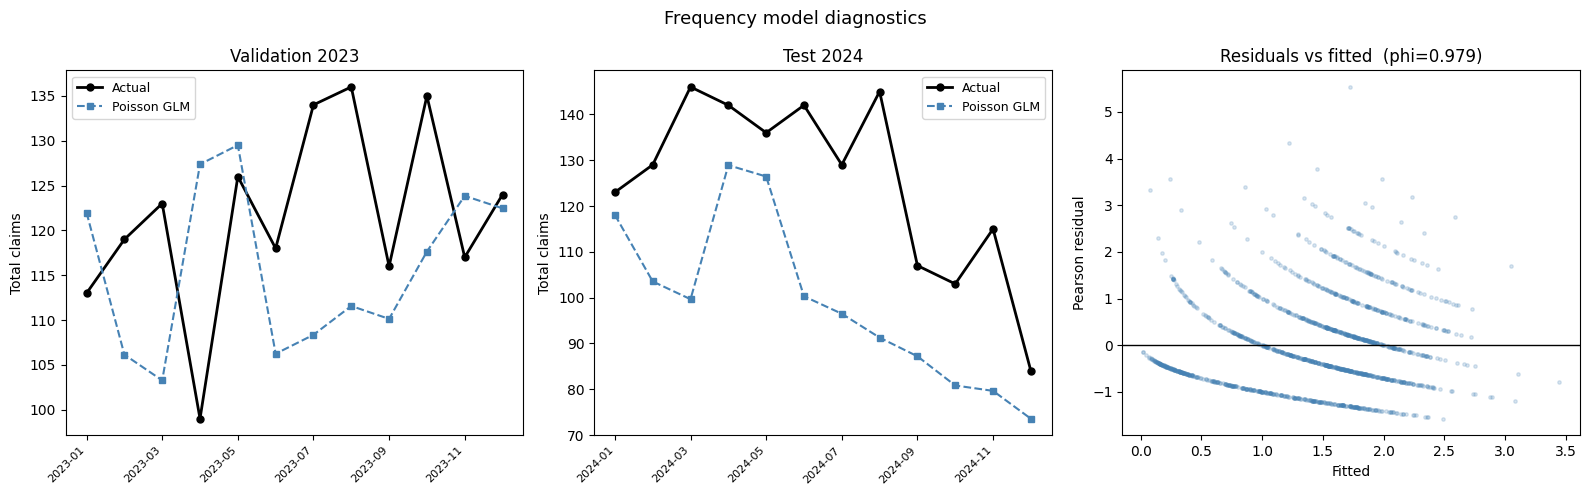

NB grid search — confirms Poisson is correct:
  alpha=0.1  AIC=4139.1  ΔAIC=+14.3  alpha_hat=1.0000  val MAE=1.1791
  alpha=0.5  AIC=4298.1  ΔAIC=+173.3  alpha_hat=1.0000  val MAE=1.1839
  alpha=1.0  AIC=4529.1  ΔAIC=+404.4  alpha_hat=1.0000  val MAE=1.1889


  alpha=5.0  AIC=5812.8  ΔAIC=+1688.0  alpha_hat=1.0000  val MAE=1.2152
→ NB rejected: alpha_hat=1.0, AIC worse than Poisson throughout.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Time series — validation
ts_val  = va_seg.groupby('year_month')[['claim_count','pred_freq']].sum()
ts_test = te_seg.groupby('year_month')[['claim_count','pred_freq']].sum()
for ax, ts, title in [(axes[0],ts_val,'Validation 2023'),(axes[1],ts_test,'Test 2024')]:
    idx = range(len(ts))
    ax.plot(idx, ts['claim_count'], 'o-',  color='black',     lw=2,   ms=5, label='Actual')
    ax.plot(idx, ts['pred_freq'],   's--', color='steelblue', lw=1.5, ms=4, label='Poisson GLM')
    ax.set_xticks(idx[::2])
    ax.set_xticklabels(ts.index[::2], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Total claims'); ax.set_title(title); ax.legend(fontsize=9)

# Pearson residuals
pear = ((tr_seg['claim_count'] - freq_model.fittedvalues)
        / np.sqrt(freq_model.fittedvalues.clip(1e-9)))
axes[2].scatter(freq_model.fittedvalues, pear, alpha=0.2, s=6, color='steelblue')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xlabel('Fitted'); axes[2].set_ylabel('Pearson residual')
axes[2].set_title(f'Residuals vs fitted  (phi={phi_freq:.3f})')

plt.suptitle('Frequency model diagnostics', fontsize=13)
plt.tight_layout(); plt.show()

# NB confirmation
print('NB grid search — confirms Poisson is correct:')
for alpha in [0.1, 0.5, 1.0, 5.0]:
    try:
        m = smf.glm(FREQ_FORMULA, tr_seg,
                    family=sm.families.NegativeBinomial(alpha=alpha, link=sm.families.links.Log()),
                    offset=tr_seg['log_exposure']).fit(maxiter=200)
        pv = m.predict(va_seg, offset=va_seg['log_exposure'])
        print(f'  alpha={alpha}  AIC={m.aic:.1f}  ΔAIC={m.aic-freq_model.aic:+.1f}'
              f'  alpha_hat={m.scale:.4f}'
              f'  val MAE={mean_absolute_error(va_seg["claim_count"],pv):.4f}')
    except: pass
print('→ NB rejected: alpha_hat=1.0, AIC worse than Poisson throughout.')


## A4. Frequency — test results

In [13]:
naive_freq_t = mean_absolute_error(te_seg['claim_count'],
                                   np.full(len(te_seg), tr_seg['claim_count'].mean()))

print('=' * 62)
print(f'FREQUENCY — TEST 2024  (n={len(te_seg)}  total claims={te_seg["claim_count"].sum()})')
print('=' * 62)
for name, yt, yp in [
    ('Naive mean',  te_seg['claim_count'].values, np.full(len(te_seg), tr_seg['claim_count'].mean())),
    ('Poisson GLM', te_seg['claim_count'].values, te_seg['pred_freq'].values),
]:
    mae_  = mean_absolute_error(yt, yp)
    dev_  = poisson_deviance(yt, yp) if name != 'Naive mean' else float('nan')
    imp   = f'({(naive_freq_t-mae_)/naive_freq_t*100:+.1f}% vs naive)' if name != 'Naive mean' else ''
    print(f'  {name:<14}  MAE={mae_:.4f}  Dev={dev_:.5f}  {imp}')

print()
print('Accuracy by coverage type (test 2024):')
print(f'{"Coverage Type":<14}  {"Actual rate":>11}  {"Predicted":>10}  {"Gap":>6}')
print('-' * 46)
for cov in sorted(seg_test['Coverage_Type'].unique()):
    mask = te_seg['Coverage_Type'] == cov
    exp  = te_seg.loc[mask,'exposure_policies']
    act  = te_seg.loc[mask,'claim_count'].sum()  / exp.sum() * 1000
    pred = te_seg.loc[mask,'pred_freq'].sum()    / exp.sum() * 1000
    print(f'{cov:<14}  {act:>11.3f}  {pred:>10.3f}  {pred-act:>+6.3f}')
print('Units: claims per 1,000 active policies per month')


FREQUENCY — TEST 2024  (n=720  total claims=1501)
  Naive mean      MAE=1.2696  Dev=nan  
  Poisson GLM     MAE=1.1911  Dev=1.34666  (+6.2% vs naive)

Accuracy by coverage type (test 2024):
Coverage Type   Actual rate   Predicted     Gap
----------------------------------------------
Commercial           20.486      19.292  -1.194
Health               23.625      17.123  -6.502
Home                 22.764      18.555  -4.209
Life                 25.209      17.215  -7.994
Motor                25.712      20.156  -5.556
Travel               22.183      18.236  -3.947
Units: claims per 1,000 active policies per month


---
# Part B — Claim Severity Model

**What it predicts:** The £ cost of an individual settled claim.

**Model:** Gamma GLM — log link, Gamma variance (V(μ) = φμ²), directly models the mean.

**Why Gamma and not log-normal OLS:**
- Log-normal OLS models `log(claim_amount)` and estimates the *median* on the log scale
- Gamma GLM models `claim_amount` directly and estimates the *mean* — what pricing needs
- Gamma requires no back-transform, no smearing correction, no additional assumption
- Both use a log link so coefficients and multipliers are nearly identical
- Gamma is the theoretically correct family: strictly positive target, variance ∝ mean²

**R² ceiling:** 0.758 — within-cell residual std ≈ 0.50 is irreducible noise
(physical damage details not in the dataset).


## B1. Severity model table — features and target

In [14]:
# ── Features and target used in the severity model ──
SEV_FEATURES = [
    # Target
    'Claim_Amount',
    # Core categorical drivers
    'Claim_Type', 'Coverage_Type', 'Region',
    # Policy financials (log-transformed)
    'log_sum',        # log(Sum Insured)
    'log_prem',       # log(Annual Premium)
    'log_excess',     # log(Excess Amount)
    # Claim characteristics
    'Settlement_Days', 'settlement_band', 'Fraud_Flag',
    # Customer demographics
    'Age', 'Gender', 'income_band_clean', 'Credit_Score',
    'Tenure_Years', 'Prior_Claims_Count', 'Late_Payments_12M',
    # Policy context
    'Renewal_Count',
    # External macro & weather
    'Cpi_Inflation', 'Flood_Risk_Index', 'Avg_Rainfall_Mm',
    'Storm_Event_Flag', 'Unemployment_Rate', 'Avg_Property_Price_Gbp',
    # Seasonality
    'quarter',
]

sev_df = tr_sev[SEV_FEATURES].copy()

print('Severity model — training table')
print(f'Shape: {sev_df.shape}  (rows = settled claims in 2021–2022)')
print()
print(sev_df.head(10).to_string())
print()
print('Summary statistics (numeric columns):')
print(sev_df.select_dtypes(include='number').describe().round(2).to_string())


Severity model — training table
Shape: (1242, 25)  (rows = settled claims in 2021–2022)

   Claim_Amount Claim_Type Coverage_Type       Region  log_sum  log_prem  log_excess  Settlement_Days settlement_band  Fraud_Flag  Age Gender income_band_clean  Credit_Score  Tenure_Years  Prior_Claims_Count  Late_Payments_12M  Renewal_Count  Cpi_Inflation  Flood_Risk_Index  Avg_Rainfall_Mm  Storm_Event_Flag  Unemployment_Rate  Avg_Property_Price_Gbp  quarter
0     3070.3100   Accident        Health  East Anglia  11.6759    7.2431      6.2166              118            slow           0   45      F        inc_gt100k           720             6                   1                  0              5         0.0631            1.8300          30.4000                 0             0.0539                  328500        1
1    19384.2200   Accident         Motor       London  11.2503    6.8704      6.2166              116            slow           0   65      M       inc_60_100k           618             3

## B2. Gamma GLM

In [15]:
GAMMA_FORMULA = (
    'Claim_Amount ~ '
    'C(Claim_Type):C(Coverage_Type) + '    # interaction — each cell has own multiplier
    'C(Region) + '
    'C(income_band_clean) + C(Gender) + '
    'C(settlement_band) + '
    'Settlement_Days:C(Claim_Type) + '     # settlement slope varies by claim type
    'log_sum + log_prem + log_excess + '
    'Fraud_Flag + Age + Credit_Score + '
    'Prior_Claims_Count + Renewal_Count + '
    'Tenure_Years + Late_Payments_12M + '
    'Cpi_Inflation + Flood_Risk_Index + '
    'Avg_Rainfall_Mm + Storm_Event_Flag + '
    'Unemployment_Rate + Avg_Property_Price_Gbp + '
    'C(quarter)'
)

gamma_model = smf.glm(
    GAMMA_FORMULA, tr_sev,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit(maxiter=300)

va_sev['pred_gamma'] = gamma_model.predict(va_sev)
te_sev['pred_gamma'] = gamma_model.predict(te_sev)

phi_gam  = gamma_model.pearson_chi2 / gamma_model.df_resid
naive_sev = mean_absolute_error(va_sev['Claim_Amount'],
                                 np.full(len(va_sev), tr_sev['Claim_Amount'].mean()))
mae_gam   = mean_absolute_error(va_sev['Claim_Amount'], va_sev['pred_gamma'])
rmsle_gam = rmsle(va_sev['Claim_Amount'].values, va_sev['pred_gamma'].values)
gini_gam  = gini(va_sev['Claim_Amount'].values, va_sev['pred_gamma'].values)

print('Gamma GLM — Severity')
print(f'  AIC          = {gamma_model.aic:.1f}')
print(f'  Pearson phi  = {phi_gam:.4f}  (dispersion parameter)')
print(f'  Val MAE      = £{mae_gam:>9,.0f}  ({(naive_sev-mae_gam)/naive_sev*100:+.1f}% vs naive)')
print(f'  Val RMSLE    =  {rmsle_gam:.4f}  ({(rmsle(va_sev["Claim_Amount"].values, np.full(len(va_sev), tr_sev["Claim_Amount"].mean()))-rmsle_gam)/rmsle(va_sev["Claim_Amount"].values, np.full(len(va_sev), tr_sev["Claim_Amount"].mean()))*100:+.1f}% vs naive)')
print(f'  Val Gini     =  {gini_gam:.4f}')
print()
print(gamma_model.summary2())


Gamma GLM — Severity
  AIC          = 23919.0
  Pearson phi  = 0.2377  (dispersion parameter)
  Val MAE      = £    4,588  (+48.0% vs naive)
  Val RMSLE    =  0.5133  (+53.1% vs naive)
  Val Gini     =  -0.4344

                                       Results: Generalized linear model
Model:                              GLM                              AIC:                            23918.9525
Link Function:                      Log                              BIC:                            -8135.4536
Dependent Variable:                 Claim_Amount                     Log-Likelihood:                 -11898.   
Date:                               2026-06-02 09:11                 LL-Null:                        -13764.   
No. Observations:                   1242                             Deviance:                       278.56    
Df Model:                           60                               Pearson chi2:                   281.      
Df Residuals:                       1181   

## B3. Severity multipliers

Significant (p<0.05): 21 of 85

                                                            multiplier  ci_lo  ci_hi  p_value
C(Coverage_Type)[T.Home]                                        3.1089 2.8415 3.4015   0.0000
C(Claim_Type)[T.Natural Disaster]:C(Coverage_Type)[Travel]      4.6780 4.0097 5.4576   0.0000
C(Claim_Type)[T.Fire]:C(Coverage_Type)[Commercial]              7.5370 6.0203 9.4357   0.0000
C(Claim_Type)[T.Medical]:C(Coverage_Type)[Travel]               0.4297 0.3744 0.4932   0.0000
C(Coverage_Type)[T.Motor]                                       2.7080 2.2913 3.2006   0.0000
C(Claim_Type)[T.Theft]:C(Coverage_Type)[Home]                   0.3972 0.3380 0.4667   0.0000
C(Claim_Type)[T.Flood]:C(Coverage_Type)[Commercial]             4.4474 3.4170 5.7885   0.0000
C(Claim_Type)[T.Liability]:C(Coverage_Type)[Commercial]         3.2908 2.6411 4.1005   0.0000
C(Claim_Type)[T.Medical]:C(Coverage_Type)[Health]               0.3213 0.2592 0.3982   0.0000
C(Coverage_Type)[T.Health]  

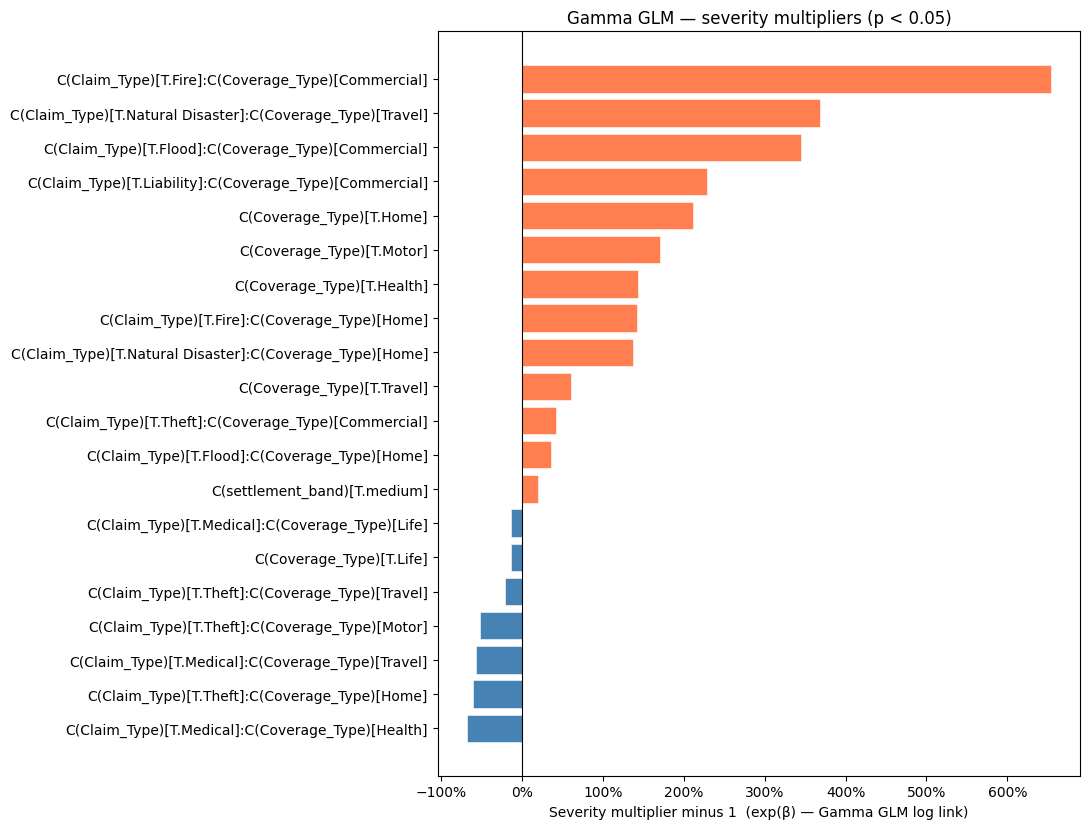

In [16]:
coef_sev = pd.DataFrame({
    'multiplier': np.exp(gamma_model.params),
    'p_value':    gamma_model.pvalues,
    'ci_lo':      np.exp(gamma_model.conf_int()[0]),
    'ci_hi':      np.exp(gamma_model.conf_int()[1]),
}).sort_values('p_value')

sig = coef_sev[coef_sev['p_value'] < 0.05].drop(index='Intercept', errors='ignore')
print(f'Significant (p<0.05): {len(sig)} of {len(coef_sev)-1}')
print()
print(sig[['multiplier','ci_lo','ci_hi','p_value']].round(4).to_string())

top_rel = (sig.assign(abs_dev=lambda d: (d['multiplier']-1).abs())
              .nlargest(min(20, len(sig)), 'abs_dev').sort_values('multiplier'))
if len(top_rel) > 0:
    fig, ax = plt.subplots(figsize=(11, max(5, len(top_rel)*0.42)))
    colors = ['coral' if v>1 else 'steelblue' for v in top_rel['multiplier']]
    ax.barh(top_rel.index, top_rel['multiplier']-1, color=colors,
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Severity multiplier minus 1  (exp(β) — Gamma GLM log link)')
    ax.set_title('Gamma GLM — severity multipliers (p < 0.05)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout()
    plt.show()


## B4. Severity — test results

In [17]:
naive_sev_t = mean_absolute_error(te_sev['Claim_Amount'],
                                   np.full(len(te_sev), tr_sev['Claim_Amount'].mean()))
print('=' * 65)
print(f'SEVERITY — TEST 2024  (n={len(te_sev):,}  total £={te_sev["Claim_Amount"].sum():,.0f})')
print('=' * 65)
for name, yt, yp in [
    ('Naive mean', te_sev['Claim_Amount'].values, np.full(len(te_sev), tr_sev['Claim_Amount'].mean())),
    ('Gamma GLM',  te_sev['Claim_Amount'].values, te_sev['pred_gamma'].values),
]:
    mae_  = mean_absolute_error(yt, yp)
    rl_   = rmsle(yt, yp)
    gi_   = gini(yt, yp) if name != 'Naive mean' else float('nan')
    imp   = f'({(naive_sev_t-mae_)/naive_sev_t*100:+.1f}% vs naive)' if name != 'Naive mean' else ''
    print(f'  {name:<12}  MAE=£{mae_:>8,.0f}  RMSLE={rl_:.4f}  Gini={gi_:.4f}  {imp}')

print()
print('Predicted vs actual by claim type:')
print(f'{"Claim Type":<18}  {"Actual":>8}  {"Gamma":>8}  {"n":>5}')
print('-' * 44)
for ct in sorted(sev_test['Claim_Type'].unique()):
    mask = te_sev['Claim_Type'] == ct
    act  = te_sev.loc[mask, 'Claim_Amount'].mean()
    gm_  = te_sev.loc[mask, 'pred_gamma'].mean()
    print(f'{ct:<18}  £{act:>7,.0f}  £{gm_:>7,.0f}  {mask.sum():>5}')

print()
print('Predicted vs actual by coverage type:')
print(f'{"Coverage Type":<14}  {"Actual":>8}  {"Gamma":>8}  {"n":>5}')
print('-' * 42)
for cv in sorted(sev_test['Coverage_Type'].unique()):
    mask = te_sev['Coverage_Type'] == cv
    act  = te_sev.loc[mask, 'Claim_Amount'].mean()
    gm_  = te_sev.loc[mask, 'pred_gamma'].mean()
    print(f'{cv:<14}  £{act:>7,.0f}  £{gm_:>7,.0f}  {mask.sum():>5}')


SEVERITY — TEST 2024  (n=871  total £=8,852,309)
  Naive mean    MAE=£   8,470  RMSLE=1.1623  Gini=nan  
  Gamma GLM     MAE=£   4,540  RMSLE=0.5461  Gini=-0.4475  (+46.4% vs naive)

Predicted vs actual by claim type:
Claim Type            Actual     Gamma      n
--------------------------------------------
Accident            £  9,884  £  9,680    136
Fire                £ 31,843  £ 29,188     63
Flood               £ 17,944  £ 21,097     70
Liability           £ 14,362  £ 14,738     80
Medical             £  2,795  £  3,046    282
Natural Disaster    £ 22,736  £ 26,701     68
Theft               £  4,435  £  4,811    172

Predicted vs actual by coverage type:
Coverage Type     Actual     Gamma      n
------------------------------------------
Commercial      £ 16,525  £ 16,692    119
Health          £  6,555  £  6,357    151
Home            £ 18,733  £ 19,604    135
Life            £  2,787  £  3,022    162
Motor           £  9,392  £ 10,207    167
Travel          £  9,834  £ 11,142 

---
# Part C — Pure Premium Model

**What it predicts:**
$$\text{pure\_premium} = \frac{\text{total\_claim\_amount}}{\text{earned\_exposure\_months}}$$

The expected annual claims cost per unit of exposure — the standard actuarial pricing target.

**Model:** Tweedie GLM (variance power p=1.5, log link, exposure as weights).

### Why no offset here (important)

The frequency model uses `log(exposure_policies)` as an offset because its
target — `claim_count` — is a raw count that grows proportionally with exposure.

Pure premium has exposure **already divided out**. It is a rate, not a count.
Adding `log(exposure)` as an offset would make the GLM estimate:

$$E[\text{PP}] = \exp(\log(\text{exposure})) \times \exp(X\beta) = \text{exposure} \times \exp(X\beta)$$

This multiplies every prediction by the exposure level. Since exposure grew from
~4 (Jan 2021, portfolio just starting) to ~12 (steady state 2023), predictions
collapsed toward zero as the portfolio stabilised — which is exactly the error
visible in the original chart.

**Fix:** Pass `earned_exposure_months` as `freq_weights` instead.
Weights tell the GLM that a segment with more exposure is more credible
(contributes more to the likelihood) without distorting the predicted level.


## C1. Pure premium model table — features and target

In [18]:
# ── Features and target used in the pure premium model ──
PP_FEATURES = [
    # Target
    'pure_premium',
    # Exposure (used as weight, NOT offset — see explanation above)
    'earned_exposure_months',
    # Categorical dimensions
    'Coverage_Type', 'Region',
    # Time
    'quarter', 'year_trend',
    # External macro & weather
    'Flood_Risk_Index', 'Cpi_Inflation', 'Unemployment_Rate',
    'Avg_Rainfall_Mm', 'Storm_Event_Flag', 'Gdp_Growth_Rate',
    'Avg_Property_Price_Gbp', 'Avg_Wind_Speed_Kmh',
]

pp_df = seg_train[PP_FEATURES].copy()

print('Pure premium model — training table')
print(f'Shape: {pp_df.shape}  (rows = segment-months in 2021–2022 with exposure > 0)')
print()
print(pp_df.head(10).to_string())
print()
print('Summary statistics:')
print(pp_df.describe().round(2).to_string())
print()
print(f'Zero pure premium rows (no claims that month): {(pp_df["pure_premium"]==0).sum()}'
      f' ({(pp_df["pure_premium"]==0).mean():.1%})')


Pure premium model — training table
Shape: (1440, 14)  (rows = segment-months in 2021–2022 with exposure > 0)

   pure_premium  earned_exposure_months Coverage_Type       Region  quarter  year_trend  Flood_Risk_Index  Cpi_Inflation  Unemployment_Rate  Avg_Rainfall_Mm  Storm_Event_Flag  Gdp_Growth_Rate  Avg_Property_Price_Gbp  Avg_Wind_Speed_Kmh
0        0.0000                  0.6229    Commercial  East Anglia        1           0            2.3600         0.0213             0.0616          35.5000                 0           0.0162                  165500              5.6000
1     9057.6680                  1.2469    Commercial  East Anglia        1           0            1.8300         0.0631             0.0539          30.4000                 0           0.0115                  328500             11.5000
2        0.0000                  1.8287    Commercial  East Anglia        1           0            2.7300         0.0351             0.0447          56.2000                 0       

## C2. Tweedie GLM

In [19]:
PP_FORMULA = (
    'pure_premium ~ '
    'C(Coverage_Type) + C(Region) + C(quarter) + year_trend + '
    'Flood_Risk_Index + Cpi_Inflation + Unemployment_Rate + '
    'Avg_Rainfall_Mm + Storm_Event_Flag + Gdp_Growth_Rate + '
    'Avg_Property_Price_Gbp + Avg_Wind_Speed_Kmh'
)

# Train on non-zero rows only (Tweedie handles zeros at prediction time)
tr_pp_nz = seg_train[seg_train['pure_premium'] > 0].copy()

tweedie_model = smf.glm(
    PP_FORMULA, tr_pp_nz,
    family=sm.families.Tweedie(
        link=sm.families.links.Log(),
        var_power=1.5          # compound Poisson-Gamma
    ),
    freq_weights=tr_pp_nz['earned_exposure_months']  # weight, NOT offset
).fit(maxiter=200)

va_seg['pred_pp'] = tweedie_model.predict(va_seg)
te_seg['pred_pp'] = tweedie_model.predict(te_seg)

phi_pp   = tweedie_model.pearson_chi2 / tweedie_model.df_resid
naive_pp = mean_absolute_error(va_seg['pure_premium'],
                                np.full(len(va_seg), seg_train['pure_premium'].mean()))
mae_pp   = mean_absolute_error(va_seg['pure_premium'], va_seg['pred_pp'])
rl_pp    = rmsle(va_seg['pure_premium'].values, va_seg['pred_pp'].values)

print('Tweedie GLM (p=1.5, log link, exposure as weights)')
print(f'  AIC          = {tweedie_model.aic:.1f}')
print(f'  Pearson phi  = {phi_pp:.4f}')
print(f'  Val MAE      = £{mae_pp:>9,.0f}  ({(naive_pp-mae_pp)/naive_pp*100:+.1f}% vs naive)')
print(f'  Val RMSLE    =  {rl_pp:.4f}')
print()
print(tweedie_model.summary2())


Tweedie GLM (p=1.5, log link, exposure as weights)
  AIC          = 144692.4
  Pearson phi  = 32.5842
  Val MAE      = £    1,386  (+20.7% vs naive)
  Val RMSLE    =  2.8366

                     Results: Generalized linear model
Model:                   GLM                 AIC:               144692.3947
Link Function:           Log                 BIC:               185109.1700
Dependent Variable:      pure_premium        Log-Likelihood:    -72319.    
Date:                    2026-06-02 09:11    LL-Null:           -74663.    
No. Observations:        1015                Deviance:          2.5897e+05 
Df Model:                26                  Pearson chi2:      2.67e+05   
Df Residuals:            8193                Scale:             32.584     
Method:                  IRLS                                              
---------------------------------------------------------------------------
                            Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------

## C3. Pure premium diagnostics — time series

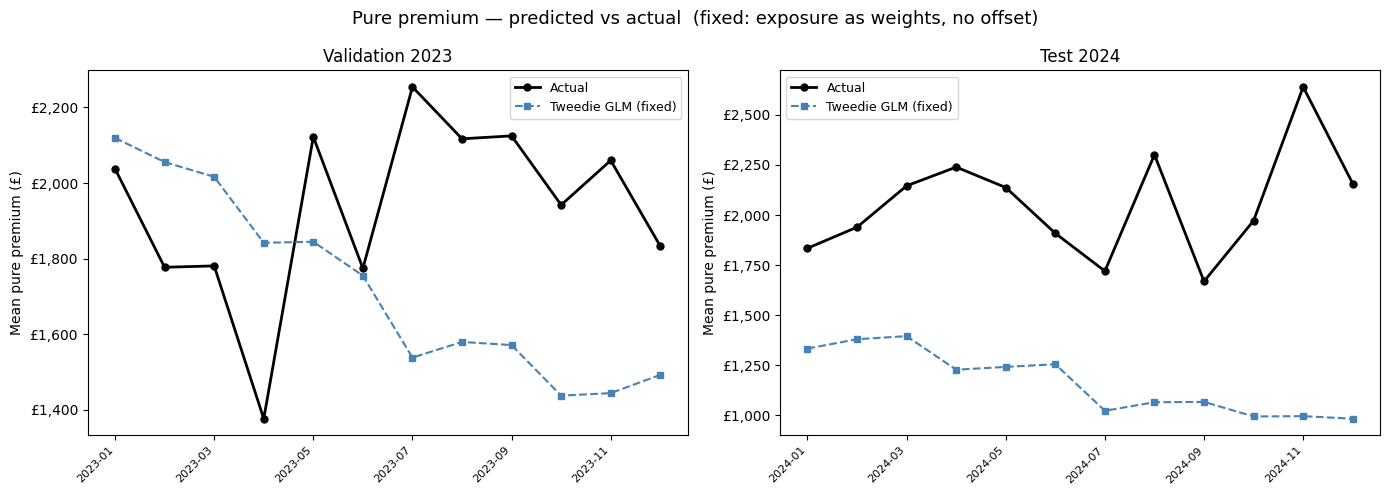

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts_val  = va_seg.groupby('year_month')[['pure_premium','pred_pp']].mean()
ts_test = te_seg.groupby('year_month')[['pure_premium','pred_pp']].mean()

for ax, ts, title in [(axes[0],ts_val,'Validation 2023'),(axes[1],ts_test,'Test 2024')]:
    idx = range(len(ts))
    ax.plot(idx, ts['pure_premium'], 'o-',  color='black',     lw=2,   ms=5, label='Actual')
    ax.plot(idx, ts['pred_pp'],      's--', color='steelblue', lw=1.5, ms=4, label='Tweedie GLM (fixed)')
    ax.set_xticks(idx[::2])
    ax.set_xticklabels(ts.index[::2], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean pure premium (£)'); ax.set_title(title); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

plt.suptitle('Pure premium — predicted vs actual  (fixed: exposure as weights, no offset)',
             fontsize=13)
plt.tight_layout(); plt.show()


## C4. Pure premium relativities

Pure premium relativities (all coefficients):
                            relativity     ci_lo     ci_hi  p_value
Intercept                    8214.4096 6780.9339 9950.9191   0.0000
C(Coverage_Type)[T.Life]        0.1715    0.1600    0.1838   0.0000
C(Coverage_Type)[T.Health]      0.3978    0.3740    0.4231   0.0000
year_trend                      0.6717    0.6446    0.7000   0.0000
C(Coverage_Type)[T.Motor]       0.6042    0.5713    0.6389   0.0000
C(Coverage_Type)[T.Travel]      0.6584    0.6220    0.6969   0.0000
C(quarter)[T.4]                 0.7184    0.6783    0.7608   0.0000
C(quarter)[T.3]                 0.7782    0.7319    0.8276   0.0000
C(Coverage_Type)[T.Home]        1.2010    1.1404    1.2648   0.0000
C(Region)[T.Scotland]           1.3053    1.2053    1.4136   0.0000
C(Region)[T.South East]         1.2858    1.1837    1.3966   0.0000
C(Region)[T.Midlands]           1.1680    1.0780    1.2655   0.0001
Avg_Rainfall_Mm                 0.9925    0.9885    0.9965   0.0003
C(

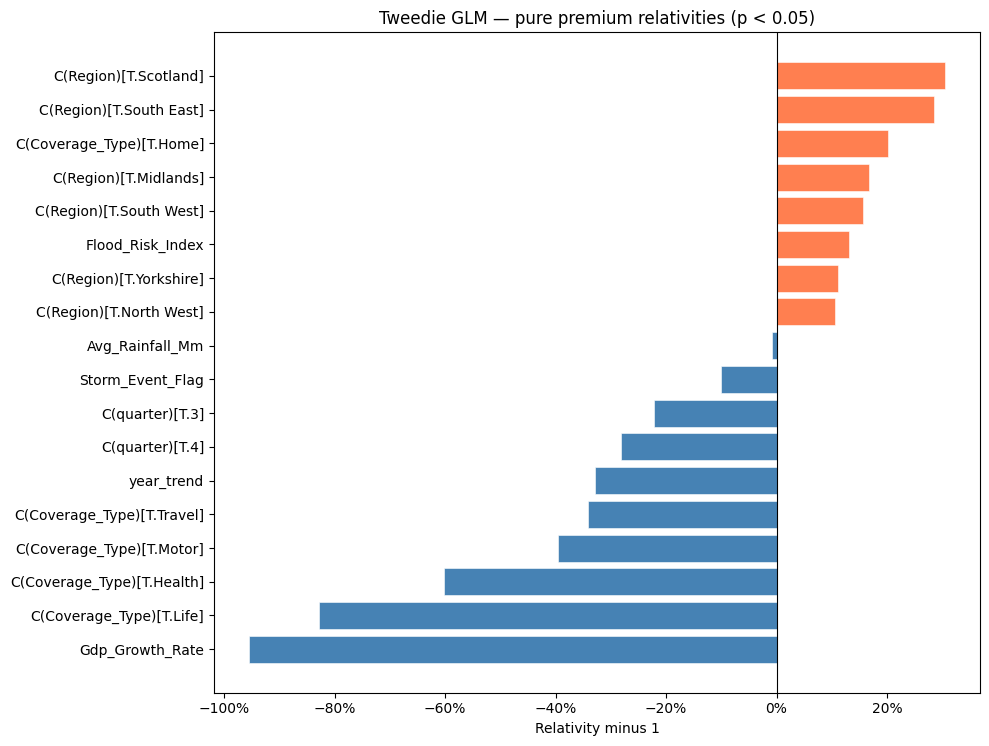

In [21]:
coef_pp = pd.DataFrame({
    'relativity': np.exp(tweedie_model.params),
    'p_value':    tweedie_model.pvalues,
    'ci_lo':      np.exp(tweedie_model.conf_int()[0]),
    'ci_hi':      np.exp(tweedie_model.conf_int()[1]),
}).sort_values('p_value')

print('Pure premium relativities (all coefficients):')
print(coef_pp[['relativity','ci_lo','ci_hi','p_value']].round(4).to_string())

sig_pp = coef_pp[(coef_pp['p_value'] < 0.05) & (coef_pp.index != 'Intercept')]
if len(sig_pp) > 0:
    top = sig_pp.assign(abs_dev=lambda d: (d['relativity']-1).abs()).nlargest(20,'abs_dev').sort_values('relativity')
    fig, ax = plt.subplots(figsize=(10, max(4, len(top)*0.42)))
    colors = ['coral' if v>1 else 'steelblue' for v in top['relativity']]
    ax.barh(top.index, top['relativity']-1, color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Relativity minus 1')
    ax.set_title('Tweedie GLM — pure premium relativities (p < 0.05)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    plt.tight_layout(); plt.show()
else:
    print('No significant numeric features — categorical terms drive the model.')


## C5. Pure premium — test results

In [22]:
naive_pp_t = mean_absolute_error(te_seg['pure_premium'],
                                  np.full(len(te_seg), seg_train['pure_premium'].mean()))

print('=' * 62)
print(f'PURE PREMIUM — TEST 2024  (n={len(te_seg)})')
print('=' * 62)
for name, yt, yp in [
    ('Naive mean',   te_seg['pure_premium'].values, np.full(len(te_seg), seg_train['pure_premium'].mean())),
    ('Tweedie GLM',  te_seg['pure_premium'].values, te_seg['pred_pp'].values),
]:
    mae_ = mean_absolute_error(yt, yp)
    rl_  = rmsle(yt, yp)
    imp  = f'({(naive_pp_t-mae_)/naive_pp_t*100:+.1f}%)' if name != 'Naive mean' else ''
    print(f'  {name:<14}  MAE=£{mae_:>8,.0f}  RMSLE={rl_:.4f}  {imp}')

print()
print('Pure premium by coverage type (test 2024):')
print(f'{"Coverage Type":<14}  {"Actual PP":>9}  {"Predicted":>10}  {"Annualised":>11}  {"Exposure":>10}')
print('-' * 58)
for cov in sorted(seg_test['Coverage_Type'].unique()):
    mask = te_seg['Coverage_Type'] == cov
    exp  = te_seg.loc[mask,'earned_exposure_months']
    act  = te_seg.loc[mask,'pure_premium'].mean()
    pred = te_seg.loc[mask,'pred_pp'].mean()
    ann  = pred * 12
    print(f'{cov:<14}  £{act:>8,.0f}  £{pred:>9,.0f}  £{ann:>10,.0f}  {exp.sum():>10.1f}')


PURE PREMIUM — TEST 2024  (n=720)
  Naive mean      MAE=£   1,811  RMSLE=3.0784  
  Tweedie GLM     MAE=£   1,521  RMSLE=2.7578  (+16.0%)

Pure premium by coverage type (test 2024):
Coverage Type   Actual PP   Predicted   Annualised    Exposure
----------------------------------------------------------
Commercial      £   2,843  £    1,731  £    20,777      1286.2
Health          £   1,287  £      689  £     8,265      1222.0
Home            £   3,669  £    2,080  £    24,954      1244.8
Life            £     615  £      297  £     3,563      1252.1
Motor           £   2,134  £    1,046  £    12,553      1246.2
Travel          £   1,785  £    1,140  £    13,679      1244.8


---
# Summary

In [23]:
print('=' * 72)
print('FINAL RESULTS — TEST SET 2024')
print('=' * 72)

naive_f_t = mean_absolute_error(te_seg['claim_count'],
                                 np.full(len(te_seg), tr_seg['claim_count'].mean()))
naive_s_t = mean_absolute_error(te_sev['Claim_Amount'],
                                 np.full(len(te_sev), tr_sev['Claim_Amount'].mean()))
naive_p_t = mean_absolute_error(te_seg['pure_premium'],
                                 np.full(len(te_seg), seg_train['pure_premium'].mean()))

print(f'\nFREQUENCY  (Poisson GLM)')
mae_ft = mean_absolute_error(te_seg['claim_count'], te_seg['pred_freq'])
print(f'  MAE      = {mae_ft:.4f}  ({(naive_f_t-mae_ft)/naive_f_t*100:+.1f}% vs naive)')
print(f'  Deviance = {poisson_deviance(te_seg["claim_count"].values, te_seg["pred_freq"].values):.5f}')
print(f'  phi      = {phi_freq:.4f}  — Poisson correct, NB rejected')

print(f'\nSEVERITY   (Gamma GLM)')
mae_st = mean_absolute_error(te_sev['Claim_Amount'], te_sev['pred_gamma'])
rl_st  = rmsle(te_sev['Claim_Amount'].values, te_sev['pred_gamma'].values)
print(f'  MAE      = £{mae_st:,.0f}  ({(naive_s_t-mae_st)/naive_s_t*100:+.1f}% vs naive)')
print(f'  RMSLE    = {rl_st:.4f}')
print(f'  phi      = {phi_gam:.4f}  (Gamma dispersion)')

print(f'\nPURE PREMIUM  (Tweedie GLM, p=1.5, exposure as weights)')
mae_pt = mean_absolute_error(te_seg['pure_premium'], te_seg['pred_pp'])
rl_pt  = rmsle(te_seg['pure_premium'].values, te_seg['pred_pp'].values)
print(f'  MAE      = £{mae_pt:,.0f}  ({(naive_p_t-mae_pt)/naive_p_t*100:+.1f}% vs naive)')
print(f'  RMSLE    = {rl_pt:.4f}')

print()
print('Annualised pure premium by coverage type (test 2024):')
for cov in sorted(seg_test['Coverage_Type'].unique()):
    mask   = te_seg['Coverage_Type'] == cov
    pp_ann = te_seg.loc[mask, 'pred_pp'].mean() * 12
    print(f'  {cov:<14}  £{pp_ann:,.0f}')



FINAL RESULTS — TEST SET 2024

FREQUENCY  (Poisson GLM)
  MAE      = 1.1911  (+6.2% vs naive)
  Deviance = 1.34666
  phi      = 0.9791  — Poisson correct, NB rejected

SEVERITY   (Gamma GLM)
  MAE      = £4,540  (+46.4% vs naive)
  RMSLE    = 0.5461
  phi      = 0.2377  (Gamma dispersion)

PURE PREMIUM  (Tweedie GLM, p=1.5, exposure as weights)
  MAE      = £1,521  (+16.0% vs naive)
  RMSLE    = 2.7578

Annualised pure premium by coverage type (test 2024):
  Commercial      £20,777
  Health          £8,265
  Home            £24,954
  Life            £3,563
  Motor           £12,553
  Travel          £13,679


In [24]:
freq_out = te_seg[['Coverage_Type','Region','year_month',
                     'claim_count','exposure_policies','pred_freq']].copy()
freq_out.to_csv('/home/claude/output_freq.csv', index=False)

sev_out  = te_sev[['Claim_Id','Policy_Id','Coverage_Type','Claim_Type',
                    'Region','year_month','Claim_Amount','pred_gamma']].copy()
sev_out.to_csv('/home/claude/output_sev.csv', index=False)

pp_out   = te_seg[['Coverage_Type','Region','year_month','total_claim_amount',
                    'earned_exposure_months','pure_premium','pred_pp']].copy()
pp_out.to_csv('/home/claude/output_pp.csv', index=False)

print(f'output_freq.csv  ({len(freq_out):,} rows)')
print(f'output_sev.csv   ({len(sev_out):,} rows)')
print(f'output_pp.csv    ({len(pp_out):,} rows)')


output_freq.csv  (720 rows)
output_sev.csv   (871 rows)
output_pp.csv    (720 rows)
